In [ ]:
import pandas as pd

**Questions**

In [ ]:
#reading 2025 data
df = pd.read_csv('/content/incidents_2025.csv')
print(df)
#reading 2026 data
df2 = pd.read_csv('/content/incidents_2026.csv')

                                                 the_geom  cartodb_id  \
0       0101000020E610000034D87A0A89CB52C02834C6AA68F5...           1   
1       0101000020E61000006085A41489CF52C010B29AEBCAF4...           2   
2       0101000020E6100000483D5F41A7C952C010D2996F95F7...           3   
3       0101000020E61000001C788C5D48C752C06028B3F01EFE...           4   
4       0101000020E61000007C8662EB0CC652C0F83367106E06...           5   
...                                                   ...         ...   
152550  0101000020E61000004652DA3499CB52C0A576D036C8F6...     3568157   
152551  0101000020E6100000F445ADF691C952C032569BFFD7F7...     3568158   
152552  0101000020E6100000152A8B040BC552C0C462ED529704...     3568159   
152553  0101000020E610000094A46B26DFCE52C018B0E42A16F1...     3568160   
152554  0101000020E6100000D8F6D104A5CE52C08EDDECACE9FA...     3568161   

                                     the_geom_webmercator  objectid  dc_dist  \
0       0101000020110F0000252B547DE0EC5FC18

In [ ]:
#Reformatting and renaming Philly data
#renaming columns
df = df.rename(columns={"text_general_code":"Crime Description","location_block":"Location", "the_geom_webmercator": "WebMercator"})
#dropping x and y (already have lat and long)
df = df.drop(columns = ["point_x", "point_y"])


In [ ]:
#Question 1: Which neighborhoods (districts) have the highest total number of crimes?
#sorting by district crime couts
district_counts = df["dc_dist"].value_counts().sort_values(ascending=False)
print(district_counts)


dc_dist
9     13248
15    12158
22    11009
24    10925
25    10080
19     9083
2      8709
14     8626
12     8064
35     7951
39     7284
26     7037
18     6608
3      6497
8      5963
16     4797
17     4763
7      3679
1      3037
5      2221
77      816
Name: count, dtype: int64


Answer for Q1:
The top 5 police districts with highest crime are 15,24,22,9, and 25

In [ ]:
#Question 2: Which type of crime is most common in each neighborhood?
df.groupby("dc_dist")['Crime Description'].agg(pd.Series.mode)

,Crime Description
dc_dist,
1,Thefts
2,Thefts
3,Thefts
5,Thefts
7,Thefts
8,Thefts
9,Thefts
12,Thefts
14,Other Assaults


Answer for Question 2:


In [ ]:
#Question 3: Which type of crime is most common in general?
crime_counts = df["Crime Description"].value_counts().sort_values(ascending=False)
print(crime_counts)
#The top 5 crimes are theft, other assaults, misc offenses, and motor vehicle theft, V


Crime Description
Thefts                                     36888
Other Assaults                             26642
All Other Offenses                         16449
Motor Vehicle Theft                        14592
Vandalism/Criminal Mischief                12656
Theft from Vehicle                          9771
Fraud                                       8933
Aggravated Assault No Firearm               5428
Burglary Residential                        3122
Narcotic / Drug Law Violations              2451
Weapon Violations                           2320
Aggravated Assault Firearm                  2251
Robbery No Firearm                          2228
Burglary Non-Residential                    1373
Robbery Firearm                             1257
Receiving Stolen Property                   1172
Disorderly Conduct                           955
Other Sex Offenses (Not Commercialized)      950
DRIVING UNDER THE INFLUENCE                  795
Rape                                         637
Ar

In [ ]:
#Question 4: What time periods have the highest rates of crime for each neighborhood?
most_frequent_hour = df["hour"].value_counts().sort_values(ascending=False)
print(most_frequent_hour)
#The top 5 hours where crime happens are 4 PM, 5 PM, 10 AM , 11 AM, 9 AM

hour
16    11334
17    10699
9     10110
11     9798
10     9679
12     9606
18     9248
13     9165
15     8031
19     7993
8      7818
14     6882
20     6854
21     5511
0      4366
23     4078
7      4044
22     3826
1      3362
2      2717
3      2190
4      1794
5      1743
6      1707
Name: count, dtype: int64


In [ ]:
#Question 5: How does crime change throughout the year (does winter and cold increase crime rates? etc..)

#function to extract month from data
def extract_month(date):
    temp = date.split("-")
    month = temp[1]
    return int(month)
#setting season based on month
def season_determining(date):
    month = extract_month(date)
    if month >= 3 and month <= 5:
        season = "Spring"
        return season
    elif month >= 6 and month <= 8:
        season = "Summer"
        return season
    elif month >= 9 and month <= 11:
        season = "Fall"
        return season
    elif month <= 2 or month == 12:
        season = "Winter"
        return season
#applying function and creating new data column
df['Seasons'] = df['dispatch_date'].apply(season_determining)
#sorting new data column
season_counts = df["Seasons"].value_counts().sort_values(ascending=False)
print(season_counts)

Seasons
Summer    42032
Fall      40277
Spring    36236
Winter    34010
Name: count, dtype: int64


In [ ]:
#Question 6: What is the average police dispatch time to each district or(taking into account crime severity)
#dictionary to map crime to priority
priority = {


    "Homicide - Criminal": 1,
    "Rape": 1,
    "Robbery Firearm": 1,
    "Aggravated Assault Firearm": 1,


    "Robbery No Firearm": 2,
    "Aggravated Assault No Firearm": 2,
    "Weapon Violations": 2,
    "Arson": 2,
    "Other Sex Offenses (Not Commercialized)": 2,
    "Offenses Against Family and Children": 2,


    "Burglary Residential": 3,
    "Burglary Non-Residential": 3,
    "Motor Vehicle Theft": 3,
    "Theft from Vehicle": 3,
    "Receiving Stolen Property": 3,
    "Narcotic / Drug Law Violations": 3,
    "DRIVING UNDER THE INFLUENCE": 3,
    "Other Assaults": 3,


    "Thefts": 4,
    "Fraud": 4,
    "Forgery and Counterfeiting": 4,
    "Embezzlement": 4,
    "Vandalism/Criminal Mischief": 4,
    "All Other Offenses": 4,
    "Disorderly Conduct": 4,
    "Public Drunkenness": 4,
    "Liquor Law Violations": 4,
    "Prostitution and Commercialized Vice": 4,
    "Vagrancy/Loitering": 4,
}

#response times estimated based on Philadelphia police data
response_times = {
    1: 508,     # 8 min 43 sec
    2: 900,     # 15 min
    3: 1800,    # 30 min
    4: 7200     # 2 hours
}

#mapping crime description to priority in dataframe

df["Priority"] = df["Crime Description"].map(priority)

#filling N/A categories with lowest priority

df["Priority"] = df["Priority"].fillna(4)
#mapping priority to dispatch time
df["ExpectedDispatch"] = df["Priority"].map(response_times)

#average dispatch time by district
district_avg = (df.groupby("dc_dist")["ExpectedDispatch"].mean())

print(district_avg.sort_values())
#Fastest dispatch in 2025 is District 19 with 1.08 hours
#Slowest in 2025 is 77 with 1.71 hours

dc_dist
35    3900.523708
22    3927.369243
26    3957.777462
39    3986.418451
14    4085.514491
12    4153.416171
19    4168.749532
16    4174.557432
25    4336.924206
15    4346.481329
5     4417.046376
3     4471.958750
7     4481.995107
24    4577.399359
18    4627.161017
8     4778.661077
2     4781.915260
1     4906.727692
9     5013.674819
17    5147.287844
77    6152.828431
Name: ExpectedDispatch, dtype: float64


In [ ]:
#Question 7: Which police service area has the most crimes committed
psa_counts = df["psa"].value_counts().sort_values(ascending=False)
print(psa_counts)
#The top 5 police service areas(2025) with highest crime are 2(48777 crimes), 1(45074 crimes),
#3(43040 crimes), 4(13466 crimes), 5(1370) crimes), A(813 crimes)


psa
2    48777
1    45074
3    43040
4    13466
5     1370
A      813
Name: count, dtype: int64


In [ ]:
#Question 8:Do specific blocks have more crimes than others and if so then which ones have the most crimes?

loc_counts = df["Location"].value_counts().sort_values(ascending=False)
print(loc_counts.head(10))
#5500 BLOCK TULIP ST has the most crimes (546)

Location
5500 BLOCK TULIP ST                      546
3900 BLOCK ARAMINGO AVE                  465
2100 BLOCK SOUTH ST                      430
1500 BLOCK SPRUCE ST                     330
7900 BLOCK E ROOSEVELT BLV               324
9100 BLOCK FRANKFORD AVE                 323
5600 BLOCK VINE ST                       294
1600 BLOCK S CHRISTOPHER COLUMBUS BLV    287
7900 BLOCK OXFORD AVE                    285
5200 BLOCK FRANKFORD AVE                 275
Name: count, dtype: int64


In [ ]:
#Question 9: What is the average longitude and latitude of the crimes?

lat_avg = df["lat"].mean()
print("Average Lattitude is: ", lat_avg)
lon_avg = df["lng"].mean()
print("Average Longitude is: ", lon_avg)

Average Lattitude is:  39.990396414276475
Average Longitude is:  -75.14097808776407


In [ ]:
#Question 10: How does the total crimes differ from 2025 to 2026
def extract_month(date):
    temp = date.split("-")
    month = temp[1]
    return int(month)

df_new = df[df["dispatch_date"].apply(extract_month) <= 6]
twenty_six = len(df_new)


df2_new = df2[df2["dispatch_date"].apply(extract_month) <= 6]
twenty_five = len(df2_new)

print("Total Crimes in 2026 Through First 6 Months: ", twenty_six)
print("Total Crimes in 2025 Through First 6 Months: ", twenty_five)

#The total crimes through the first 6 months for both 2026 and 2025 are very similar

Total Crimes in 2026 Through First 6 Months:  72711
Total Crimes in 2025 Through First 6 Months:  72959


In [ ]:
#Question 11 How does Crime Total Reported by UPENN Police differ from Philly Police Dep
df3 = pd.read_csv("/content/upenn.csv")
#upenn.csv is what I named the file replace with your upenn police file name
print("Total Crimes Reported by UPENN Police: ", len(df3))
print("Total Crimes Reported by Philadelphia Police Dep: ", len(df))

#The vast majority of crimes are not handled by Upenn Police

Total Crimes Reported by UPENN Police:  411
Total Crimes Reported by Philadelphia Police Dep:  152555


In [ ]:
#Question 12 Which UCR General Has The Most Crimes?
ucr_counts = df["ucr_general"].value_counts().sort_values(ascending=False)
print(ucr_counts)
#UCR General 600 has the most

ucr_general
600     46659
800     26642
2600    16449
700     14592
1400    12656
1100     8933
400      7679
500      4495
300      3485
1800     2451
1500     2320
1300     1172
2400      955
1700      950
2100      795
200       637
900       564
2000      312
100       222
1600      209
1200      143
1000       84
2300       73
2500       39
2200       35
1900        4
Name: count, dtype: int64


# **Pie Chart**

In [ ]:
import matplotlib.pyplot as plt

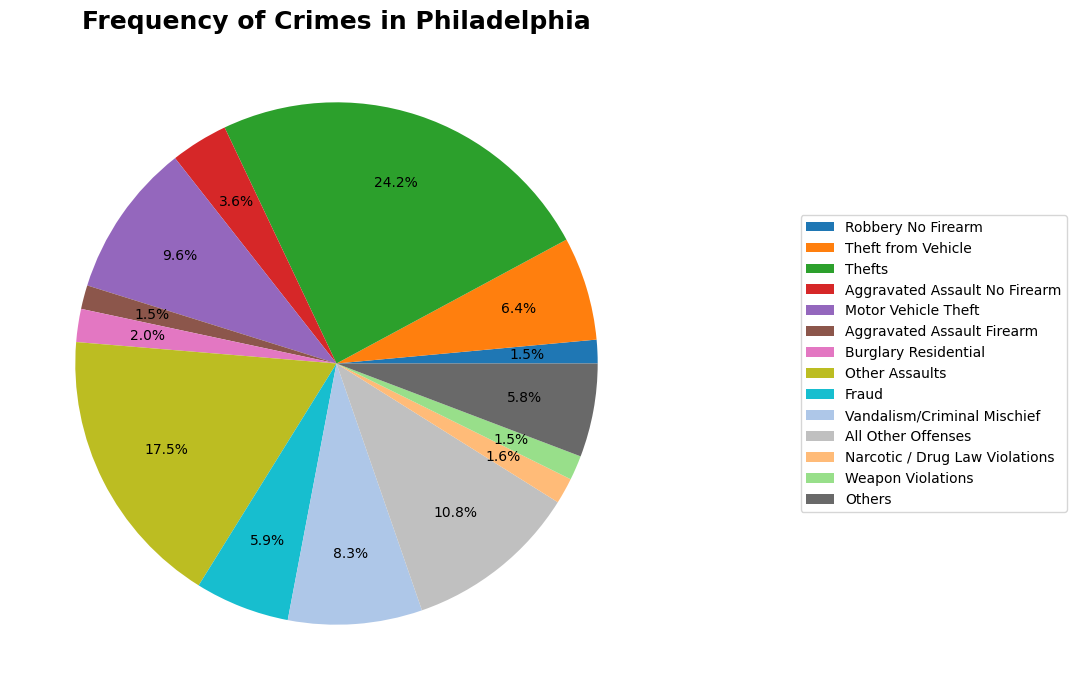

In [ ]:
# Pie Chart
data = {}
crime = df['Crime Description']

for i in crime:
  if i not in data.keys():
    data[i] =1
  else:
    data[i] += 1

data["Others"] = 0
de = []
for k,v in data.items():
  if v <= 0.01 * len(crime):
    data['Others'] += v
    de.append(k)

for i in de:
  del data[i]

labels = data.keys()
sizes = data.values()

plt.figure(figsize=(10, 8))


default_colors = [
    '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728',
    '#9467bd', '#8c564b', '#e377c2', '#bcbd22',
    '#17becf', '#aec7e8', '#ffbb78', '#98df8a',
    '#ff9896'
]

special_colors = {
    "Others": "#696969",
    "All Other Offenses": "#C0C0C0"
}

colors = []
i = 0
for label in labels:
    if label in special_colors:
        colors.append(special_colors[label])
    else:
        colors.append(default_colors[i % len(default_colors)])
        i += 1

plt.pie(
    sizes,
    colors=colors,
    pctdistance=0.73,
    autopct='%1.1f%%'
)



plt.legend(labels=labels,loc="center left", bbox_to_anchor=(1.2, 0.5))
plt.title('Frequency of Crimes in Philadelphia', fontsize=18,fontweight="bold")
plt.tight_layout()
plt.savefig("piechart.png",dpi=300,bbox_inches="tight")
plt.show()

#All other offenses is a category in the police data, there is no information on what it contains


# **Bar Chart**

In [ ]:
import re

def extract_area_name(location):
    """
    Examples:
    'N 29TH ST & W HUNTINGDON ST' -> '29TH ST'
    '3300 BLOCK N ORKNEY ST'      -> 'ORKNEY ST'
    '500 BLOCK W MARKET ST'       -> 'MARKET ST'
    """

    if pd.isna(location):
        return pd.NA

    location = str(location).upper().strip()

    # remove the block number and BLOCK/BLK
    location = re.sub(
        r"^\d+\s+(?:BLOCK|BLK)\s+(?:OF\s+)?",
        "",
        location
    )

    # for intersections, keep only the first street
    location = location.split("&", maxsplit=1)[0].strip()

    # remove N, S, E, or W from the beginning
    location = re.sub(
        r"^(?:N|S|E|W)\s+",
        "",
        location
    )

    # remove apartment, floor, unit, room, or suite information
    location = re.sub(
        r"\s+(?:APT|APARTMENT|UNIT|FL|FLOOR|RM|ROOM|STE|SUITE)\s+.*$",
        "",
        location
    )

    # clean extra spaces and punctuation
    location = re.sub(r"\s+", " ", location)
    location = location.strip(" ,.-")

    if location in {"", "UNKNOWN", "UNK"}:
        return pd.NA

    return location


# apply the function to location_block
df["area_name"] = df["Location"].apply(extract_area_name)


# display the original and cleaned location columns
print(df[["Location", "area_name"]].head(20))

                           Location              area_name
0            1900 BLOCK Johnston St            JOHNSTON ST
1             2500 BLOCK ISLAND AVE             ISLAND AVE
2               1100 BLOCK S 4TH ST                 4TH ST
3             2900 BLOCK Memphis St             MEMPHIS ST
4         6400 BLOCK RISING SUN AVE         RISING SUN AVE
5   300 BLOCK MARTIN LUTHER KING DR  MARTIN LUTHER KING DR
6              1400 BLOCK S 10TH ST                10TH ST
7       4100 BLOCK PRESIDENTIAL BLV       PRESIDENTIAL BLV
8          7400 BLOCK BUSTLETON AVE          BUSTLETON AVE
9      2800 BLOCK W SUSQUEHANNA AVE        SUSQUEHANNA AVE
10          6000 BLOCK WOODLAND AVE           WOODLAND AVE
11             1300 BLOCK ARROTT ST              ARROTT ST
12             1200 BLOCK LOCUST ST              LOCUST ST
13        4400 BLOCK RISING SUN AVE         RISING SUN AVE
14         5100 BLOCK LANCASTER AVE          LANCASTER AVE
15            7900 BLOCK OXFORD AVE             OXFORD A

In [ ]:
streets = pd.read_csv("/content/CompleteStreets.csv")
streets['street'] = streets['ST_NAME'].astype(str) + ' ' + streets['ST_TYPE'].astype(str).apply(extract_area_name).apply(extract_area_name)
str_dic = {}
for i in range(len(streets)):
  if streets.iloc[i, 4] not in str_dic.keys():
    str_dic[streets.iloc[i, 4]] = streets.iloc[i, 1]
  else:
    str_dic[streets.iloc[i, 4]] += streets.iloc[i, 1]

print(str_dic)
df['length'] = df['area_name'].map(str_dic)
df.head(30)

{'STEVENSON ST': np.float64(6629.4377827), 'FALLS RD': np.float64(3314.1083639), '66TH ST': np.float64(12445.87307234), '29TH ST': np.float64(18063.09814421), 'RIDGE AVE': np.float64(54347.880351949985), '15TH ST': np.float64(51929.87703515001), 'CECIL B MOORE AVE': np.float64(15453.004066), 'BROAD ST': np.float64(92181.11898840994), 'POPLAR ST': np.float64(20051.195758769998), 'CORINTHIAN AVE': np.float64(2059.9358492), 'PENNSYLVANIA AVE': np.float64(5542.351808699999), 'FAIRMOUNT AVE': np.float64(20631.268811059996), '21ST ST': np.float64(40616.93284994001), '22ND ST': np.float64(33878.98516679002), 'RACE ST': np.float64(21296.951547479992), 'CHERRY ST': np.float64(9433.798415010002), '23RD ST': np.float64(27556.84665345), 'MARKET ST': np.float64(30143.44484382001), 'JOHN F KENNEDY BLV': np.float64(14825.35396243), '18TH ST': np.float64(44090.357910120016), '16TH ST': np.float64(52984.78777951001), 'ARCH ST': np.float64(19677.911548829998), 'LOCUST ST': np.float64(20367.573454339992)

,the_geom,cartodb_id,WebMercator,objectid,dc_dist,psa,dispatch_date_time,dispatch_date,dispatch_time,hour,...,ucr_general,Crime Description,gdb_geomattr_data,lat,lng,Seasons,Priority,ExpectedDispatch,area_name,length
0,0101000020E610000034D87A0A89CB52C02834C6AA68F5...,1,0101000020110F0000252B547DE0EC5FC1822965612984...,1,1,1,2025-08-29 18:48:00+00,2025-08-29,14:48:00,14,...,300,Robbery No Firearm,NaN,39.917257,-75.180239,Summer,2.0,900,JOHNSTON ST,4695.008156
1,0101000020E61000006085A41489CF52C010B29AEBCAF4...,2,0101000020110F00003AF38DECABF35FC1A250FBB47A83...,2,12,1,2025-06-29 10:10:00+00,2025-06-29,06:10:00,6,...,600,Theft from Vehicle,NaN,39.912443,-75.242742,Summer,3.0,1800,ISLAND AVE,33234.159132
2,0101000020E6100000483D5F41A7C952C010D2996F95F7...,3,0101000020110F00004C03D720AEE95FC14B4695FD9186...,3,3,2,2025-05-03 03:44:00+00,2025-05-02,23:44:00,23,...,300,Robbery No Firearm,NaN,39.934248,-75.150833,Spring,2.0,900,4TH ST,NaN
3,0101000020E61000001C788C5D48C752C06028B3F01EFE...,4,0101000020110F00007F7FC043A7E55FC110D4D448D08D...,4,24,3,2025-12-20 01:52:00+00,2025-12-19,20:52:00,20,...,300,Robbery No Firearm,NaN,39.985319,-75.113792,Winter,2.0,900,MEMPHIS ST,9964.652009
4,0101000020E61000007C8662EB0CC652C0F83367106E06...,5,0101000020110F00000AB1AD728FE35FC19ECF66340797...,5,2,2,2025-08-08 18:51:00+00,2025-08-08,14:51:00,14,...,600,Thefts,NaN,40.050234,-75.094539,Summer,4.0,7200,RISING SUN AVE,41603.810579
5,0101000020E6100000942D829472CB52C00868633E43FB...,6,0101000020110F0000FE7F6C56BAEC5FC10F56395FA58A...,6,9,1,2025-04-23 22:18:00+00,2025-04-23,18:18:00,18,...,300,Robbery No Firearm,NaN,39.962990,-75.178868,Spring,2.0,900,MARTIN LUTHER KING DR,30389.195735
6,0101000020E6100000742DBCF34DCA52C0E859077C48F7...,7,0101000020110F0000CE2E8A47C9EA5FC1337860C23C86...,7,3,3,2025-08-08 23:38:00+00,2025-08-08,19:38:00,19,...,600,Thefts,NaN,39.931900,-75.161008,Summer,4.0,7200,10TH ST,49888.232700
7,0101000020E6100000BC74F58B7BCD52C0D893AA6EE700...,8,0101000020110F0000497075402FF05FC1C9FD0B2BE690...,8,19,3,2025-06-02 12:27:00+00,2025-06-02,08:27:00,8,...,600,Thefts,NaN,40.007063,-75.210666,Summer,4.0,7200,PRESIDENTIAL BLV,2481.495215
8,0101000020E61000003C594FB2B7C352C0C061BA946306...,9,0101000020110F00004A22330199DF5FC1D95ADF92FB96...,9,2,3,2025-08-08 20:16:00+00,2025-08-08,16:16:00,16,...,600,Thefts,NaN,40.049914,-75.058087,Summer,4.0,7200,BUSTLETON AVE,45595.378010
9,0101000020E6100000403ED6F670CB52C0F8EAD99C98FE...,10,0101000020110F0000D4CDC297B7EC5FC149A0C427578E...,10,22,2,2025-12-06 20:56:08+00,2025-12-06,15:56:08,15,...,300,Robbery No Firearm,NaN,39.989032,-75.178770,Winter,2.0,900,SUSQUEHANNA AVE,19236.782556


In [ ]:
severity = {
    "Homicide - Criminal": 4,
    "Rape": 4,
    "Robbery Firearm": 4,
    "Aggravated Assault Firearm": 4,

    "Robbery No Firearm": 3,
    "Aggravated Assault No Firearm": 3,
    "Weapon Violations": 3,
    "Arson": 3,
    "Other Sex Offenses (Not Commercialized)": 3,
    "Offenses Against Family and Children": 3,

    "Burglary Residential": 2,
    "Burglary Non-Residential": 2,
    "Motor Vehicle Theft": 2,
    "Theft from Vehicle": 2,
    "Receiving Stolen Property": 2,
    "Narcotic / Drug Law Violations": 2,
    "DRIVING UNDER THE INFLUENCE": 2,
    "Other Assaults": 2,

    "Thefts": 1,
    "Fraud": 1,
    "Forgery and Counterfeiting": 1,
    "Embezzlement": 1,
    "Vandalism/Criminal Mischief": 1,
    "All Other Offenses": 1,
    "Disorderly Conduct": 1,
    "Public Drunkenness": 1,
    "Liquor Law Violations": 1,
    "Prostitution and Commercialized Vice": 1,
    "Vagrancy/Loitering": 1,
}

df["severity_score"] = df["Crime Description"].map(severity)
df["length"] = pd.to_numeric(df["length"], errors="coerce")

area_scores = (
    df.groupby("area_name")
    .agg(
        danger_score=("severity_score", "sum"),
        total_incidents=("severity_score", "size"),
        length=("length", "first")
    )
    .reset_index()
)

area_scores["danger_score_l"] = (
    area_scores["danger_score"]
    / area_scores["length"].replace(0, pd.NA) * 1000
)


area_scores = area_scores.sort_values(
    by=["danger_score_l", "total_incidents"],
    ascending=[False, False]
)
top_10 = area_scores.head(10)

print(top_10)

            area_name  danger_score  total_incidents        length  \
3863          PIA WAY         217.0              175    505.226385   
3018          LOCK ST          19.0               10    136.323799   
1705         DRURY ST          39.0               28    289.435708   
3446  NARRAGANSETT ST         110.0               44    843.323454   
3169        MARKET ST        3923.0             2970  30143.444844   
2414          HART LN         259.0              164   2065.137178   
4039          RENO PL          25.0               11    226.889478   
2742   KENSINGTON AVE        1515.0             1054  14537.982135   
4228          RUTH ST         360.0              254   3671.215023   
4563       STOUTON ST         120.0              101   1331.939528   

      danger_score_l  
3863      429.510426  
3018      139.374050  
1705      134.744950  
3446      130.436311  
3169      130.144382  
2414      125.415397  
4039      110.185806  
2742      104.209786  
4228       98.060178  

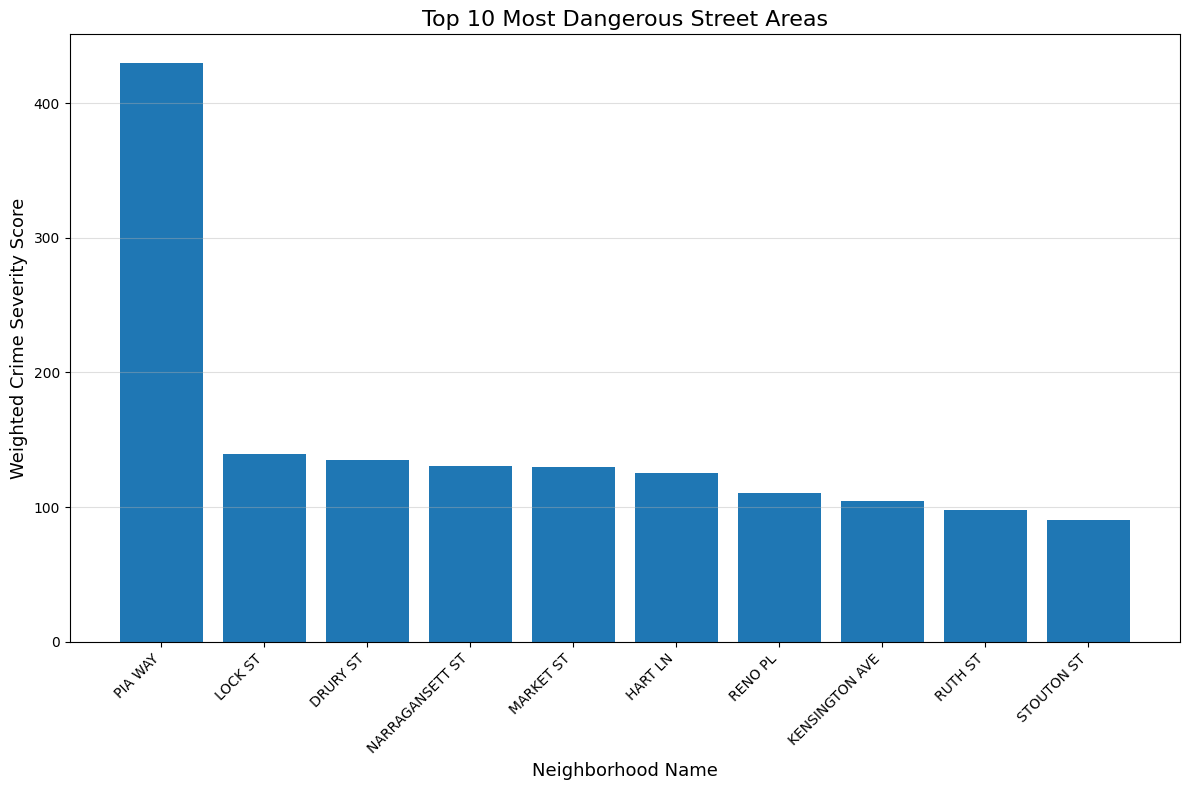

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 8))

bars = plt.bar(top_10["area_name"], top_10["danger_score_l"])
plt.title(
    "Top 10 Most Dangerous Street Areas",
    fontsize=16,)

plt.xlabel("Neighborhood Name", fontsize=13)
plt.ylabel("Weighted Crime Severity Score", fontsize=13)
plt.xticks(rotation=45, ha="right")

# add horizontal grid lines
plt.grid(
    axis="y",
    linestyle="-",
    alpha=0.4
)

plt.tight_layout()
plt.savefig("bargraph.png",dpi=300,bbox_inches="tight")
plt.show()

# **Heat Map**

In [ ]:
import folium

In [ ]:
df_map = df.dropna(subset=["lat", "lng"])


#philadelphia map boundaries

#approximate rectangular bounding box around Philadelphia
south = 39.867
north = 40.137
west = -75.280
east = -74.955

philadelphia_center = [39.9526, -75.1652]



# grid settings
number_of_rows = 110
number_of_columns = 110

latitude_step = (north - south) / number_of_rows
longitude_step = (east - west) / number_of_columns

# severity
severity = {
    "Homicide - Criminal": 4,
    "Rape": 4,
    "Robbery Firearm": 4,
    "Aggravated Assault Firearm": 4,


    "Robbery No Firearm": 3,
    "Aggravated Assault No Firearm": 3,
    "Weapon Violations": 3,
    "Arson": 3,
    "Other Sex Offenses (Not Commercialized)": 3,
    "Offenses Against Family and Children": 3,


    "Burglary Residential": 2,
    "Burglary Non-Residential": 2,
    "Motor Vehicle Theft": 2,
    "Theft from Vehicle": 2,
    "Receiving Stolen Property": 2,
    "Narcotic / Drug Law Violations": 2,
    "DRIVING UNDER THE INFLUENCE": 2,
    "Other Assaults": 2,


    "Thefts": 1,
    "Fraud": 1,
    "Forgery and Counterfeiting": 1,
    "Embezzlement": 1,
    "Vandalism/Criminal Mischief": 1,
    "All Other Offenses": 1,
    "Disorderly Conduct": 1,
    "Public Drunkenness": 1,
    "Liquor Law Violations": 1,
    "Prostitution and Commercialized Vice": 1,
    "Vagrancy/Loitering": 1,
}

df_map["weight"] = df_map["Crime Description"].map(severity)
df_map["row"] = ((df_map["lat"]-south) / latitude_step).astype(int)
df_map["column"] = ((df_map["lng"]-west) / longitude_step).astype(int)

grid_data = (df_map.groupby(["row", "column"]).agg(crime_count=("weight", "size"),weighted_score=("weight", "sum")).reset_index()
)
grid_data = grid_data.set_index(["row", "column"])
# red limit
score_limit = grid_data["weighted_score"].quantile(0.95)

# convert score to a specific color
def get_color(score):
    index_value = min(score / score_limit * 100, 100)
    if index_value == 0:
        return "#e3dfda"
    if index_value < 20:
        return "#1a9641"  # Green
    elif index_value < 40:
        return "#a6d96a"  # Light green
    elif index_value < 60:
        return "#ffffbf"  # Yellow
    elif index_value < 80:
        return "#fdae61"  # Orange
    else:
        return "#d7191c"  # Red



#create the base map

philadelphia_map = folium.Map(
    location=philadelphia_center,
    zoom_start=11,
    tiles="OpenStreetMap"
)

grid_layer = folium.FeatureGroup(
    name="Severity of Crimes in Philadelphia",
    show=True
)



# create and color the grid cells

# Add the severity level to the specific grid it belongs to (compare the latitude and longitude of the crime to the boundaries of the grid)

for row in range(number_of_rows):
    for column in range(number_of_columns):
        # The boundaries of each grid
        cell_south = south + row * latitude_step
        cell_north = cell_south + latitude_step

        cell_west = west + column * longitude_step
        cell_east = cell_west + longitude_step

        if (row, column) in grid_data.index:
            crime_count = int(
                grid_data.loc[(row, column), "crime_count"]
            )

            weighted_score = int(
                grid_data.loc[(row, column), "weighted_score"]
            )
        else:
            crime_count = 0
            weighted_score = 0

        folium.Rectangle(
            bounds=[
                [cell_south, cell_west],
                [cell_north, cell_east]
            ],
            color="#555555",
            weight=0.3,
            fill=True,
            fill_color=get_color(weighted_score),
            fill_opacity=0.40,
            tooltip=(
                f"Crime count: {crime_count}<br>"
                f"Weighted score: {weighted_score}"
            )
        ).add_to(grid_layer)


grid_layer.add_to(philadelphia_map)



#color legend

legend_html = f"""
<div style="
    position: fixed;
    bottom: 40px;
    left: 40px;
    width: 220px;
    padding: 10px;
    background: white;
    border: 2px solid grey;
    border-radius: 5px;
    z-index: 9999;
">
    <b>Weighted crime score</b>

    <div style="
        height: 18px;
        margin-top: 7px;
        background: linear-gradient(
            to right,
            #1a9641,
            #a6d96a,
            #ffffbf,
            #fdae61,
            #d7191c,
        );
    "></div>

    <div style="
        display: flex;
        justify-content: space-between;
    ">
        <span>0</span>
        <span>{score_limit:.0f}+</span>
    </div>
</div>
"""

philadelphia_map.get_root().html.add_child(
    folium.Element(legend_html)
)


# add controls and save the map

folium.LayerControl().add_to(philadelphia_map)

philadelphia_map.fit_bounds([
    [south, west],
    [north, east]
])

philadelphia_map.save("philadelphia_grid_heatmap.html")

print("Map saved as philadelphia_grid_heatmap.html")

/tmp/ipykernel_1746/3992208200.py:62: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_map["weight"] = df_map["Crime Description"].map(severity)
/tmp/ipykernel_1746/3992208200.py:63: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_map["row"] = ((df_map["lat"]-south) / latitude_step).astype(int)
/tmp/ipykernel_1746/3992208200.py:64: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the docum

Map saved as philadelphia_grid_heatmap.html


In [ ]:
print(area_scores)

            area_name  danger_score  total_incidents        length  \
3863          PIA WAY         217.0              175    505.226385   
3018          LOCK ST          19.0               10    136.323799   
1705         DRURY ST          39.0               28    289.435708   
3446  NARRAGANSETT ST         110.0               44    843.323454   
3169        MARKET ST        3923.0             2970  30143.444844   
...               ...           ...              ...           ...   
5215       WYOMING ST           2.0                1           NaN   
5223  YORK ST 2ND FLR           1.0                1           NaN   
5224        YORK ST 3           1.0                1           NaN   
5226           ZONE 7           1.0                1           NaN   
5227  `1442 N 17TH ST           1.0                1           NaN   

      danger_score_l  
3863       42.951043  
3018       13.937405  
1705       13.474495  
3446       13.043631  
3169       13.014438  
...              ... 